# Synthetic Difference-in-Differences with `pymc` models

In [1]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
from pymc_extras.prior import Prior

import causalpy as cp

In [2]:
%load_ext autoreload
%autoreload 2
%config InlineBackend.figure_format = 'retina'
seed = 42

## Methodological overview

Synthetic Difference-in-Differences (SDiD) {cite}`arkhangelsky2021synthetic` combines the strengths of the Synthetic Control (SC) method and Difference-in-Differences (DiD). Like SC, it learns **unit weights** that balance control units against the treated unit in the pre-treatment period. Like DiD, it additionally learns **time weights** that balance pre-treatment periods against post-treatment periods for control units. The treatment effect is then estimated from a weighted double-difference: the post-treatment gap between treated and synthetic control, adjusted by a time-weighted pre-treatment gap. This three-stage structure of estimating unit weights, time weights, and then treatment effect ensures that each stage uses the appropriate slice of the panel data.

Rather than placing all parameters into a single joint model (which would allow the treatment-effect likelihood to distort the weight posteriors), the weights are sampled via MCMC and the treatment effect $\tau$ is computed **analytically** from the posterior draws via the double-difference formula. This is a *cut*-posterior-inspired design: weight posteriors are insulated from the treatment effect computation, so that identification (weights) and estimation ($\tau$) remain cleanly separated. The weights are parameterised via a softmax-over-Normal-logits construction, $\omega = \mathrm{softmax}(\tilde{\omega})$, with one logit pinned to zero for identifiability.

An important feature of SDiD is the role of the regularisation parameters $\zeta_\omega$ and $\zeta_\lambda$, which in the Bayesian model correspond to the prior precision on the logits. When $\sigma_\omega = 1/\zeta_\omega$ is **small**, the logit prior is tight and the weights are pulled toward uniformity; this recovers a DiD-like estimator. When $\sigma_\omega$ is **large**, the prior is diffuse and a few well-matching controls can receive most of the weight; this recovers a SC-like estimator. The time-weight prior is typically set to be diffuse ($\zeta_\lambda \approx 0.01$), allowing the data to concentrate weight on whichever pre-treatment periods are most informative for predicting the post-treatment control outcomes.

## Load data

We use the California Proposition 99 dataset {cite}`abadie2010synthetic`, a standard benchmark for synthetic control methods. In November 1988, California imposed a 25-cent-per-pack excise tax on cigarettes along with restrictions on smoking in public spaces. The dataset contains annual per-capita cigarette sales (in packs) for 39 US states from 1970 to 2000.

Because the default priors on the matching noise ($\sigma_\omega$, $\sigma_\lambda$) and intercepts ($\omega_0$, $\lambda_0$) are calibrated for data near unit scale, we pass priors scaled to the data when working in original units.

In [3]:
df = cp.load_data("california_prop99").set_index("Year")
treatment_time = 1989
control_units = [c for c in df.columns if c != "California"]
treated_units = ["California"]

# Data scale for prior calibration
y_sd = float(df["California"].std())

print(f"Panel: {df.shape[0]} years × {df.shape[1]} states")
print(f"Pre-treatment: {(df.index < treatment_time).sum()} years (1970–1988)")
print(f"Post-treatment: {(df.index >= treatment_time).sum()} years (1989–2000)")
df.head()

Panel: 31 years × 39 states
Pre-treatment: 19 years (1970–1988)
Post-treatment: 12 years (1989–2000)


,Alabama,Arkansas,California,Colorado,Connecticut,Delaware,Georgia,Idaho,Illinois,Indiana,...,South Carolina,South Dakota,Tennessee,Texas,Utah,Vermont,Virginia,West Virginia,Wisconsin,Wyoming
Year,,,,,,,,,,,,,,,,,,,,,
1970,89.800003,100.300003,123.000000,124.800003,120.000000,155.000000,109.900002,102.400002,124.800003,134.600006,...,103.599998,92.699997,99.800003,106.400002,65.500000,122.599998,124.300003,114.500000,106.400002,132.199997
1971,95.400002,104.099998,121.000000,125.500000,117.599998,161.100006,115.699997,108.500000,125.599998,139.300003,...,115.000000,96.699997,106.300003,108.900002,67.699997,124.400002,128.399994,111.500000,105.400002,131.699997
1972,101.099998,103.900002,123.500000,134.300003,110.800003,156.300003,117.000000,126.099998,126.599998,149.199997,...,118.699997,103.000000,111.500000,108.599998,71.300003,138.000000,137.000000,117.500000,108.800003,140.000000
1973,102.900002,108.000000,124.400002,137.899994,109.300003,154.699997,119.800003,121.800003,124.400002,156.000000,...,125.500000,103.500000,109.699997,110.400002,72.699997,146.800003,143.100006,116.599998,109.500000,141.199997
1974,108.199997,109.699997,126.699997,132.800003,112.400002,151.300003,123.699997,125.599998,131.899994,159.600006,...,129.699997,108.400002,114.800003,114.699997,75.599998,151.800003,149.600006,119.900002,111.800003,145.800003


## Run the analysis

:::{note}
The `random_seed` keyword argument for the PyMC sampler is not necessary. We use it here so that the results are reproducible.
:::

In [4]:
result = cp.SyntheticDifferenceInDifferences(
    df,
    treatment_time,
    control_units=control_units,
    treated_units=treated_units,
    model=cp.pymc_models.SyntheticDifferenceInDifferencesWeightFitter(
        sample_kwargs={
            "target_accept": 0.95,
            "random_seed": seed,
            "tune": 3000,
            "draws": 2000,
        },
        priors={
            "sigma_omega": Prior("HalfNormal", sigma=y_sd),
            "sigma_lambda": Prior("HalfNormal", sigma=y_sd),
            "omega0": Prior("Normal", mu=0, sigma=y_sd * 2),
            "lambda0": Prior("Normal", mu=0, sigma=y_sd * 2),
        },
    ),
)

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [omega_raw, omega0, sigma_omega, lam_raw, lambda0, sigma_lambda]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 168 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Sampling: [lam_raw, lambda0, lambda_match, omega0, omega_match, omega_raw, sigma_lambda, sigma_omega]


Sampling: [lambda_match, omega_match]


In [5]:
tau_mean = float(result.tau_posterior.mean())
tau_hdi = az.hdi(result.tau_posterior.values.flatten(), hdi_prob=0.94)

print(f"Average treatment effect (packs per capita): {tau_mean:.1f}")
print(f"  94% HDI: [{float(tau_hdi[0]):.1f}, {float(tau_hdi[1]):.1f}]")

Average treatment effect (packs per capita): -14.3
  94% HDI: [-18.5, -9.7]


## Inspecting weight posteriors

SDiD produces two sets of weights whose posteriors we can inspect directly.

**Unit weights ($\omega$)**: These determine how much each control unit contributes to the synthetic control. If the weights are roughly uniform (close to $1/N_{\text{co}}$), the estimator behaves more like DiD. If the weights are sparse i.e., concentrating on one or two donors, then the estimator behaves more like SC. The posterior uncertainty on these weights reflects how confident the model is in the donor selection.

**Time weights ($\lambda$)**: These determine how much each pre-treatment period contributes to the baseline comparison. If the weights concentrate on later pre-treatment periods, this indicates that those periods are most informative for predicting post-treatment control outcomes. Uniform time weights would imply that all pre-treatment periods are equally useful.

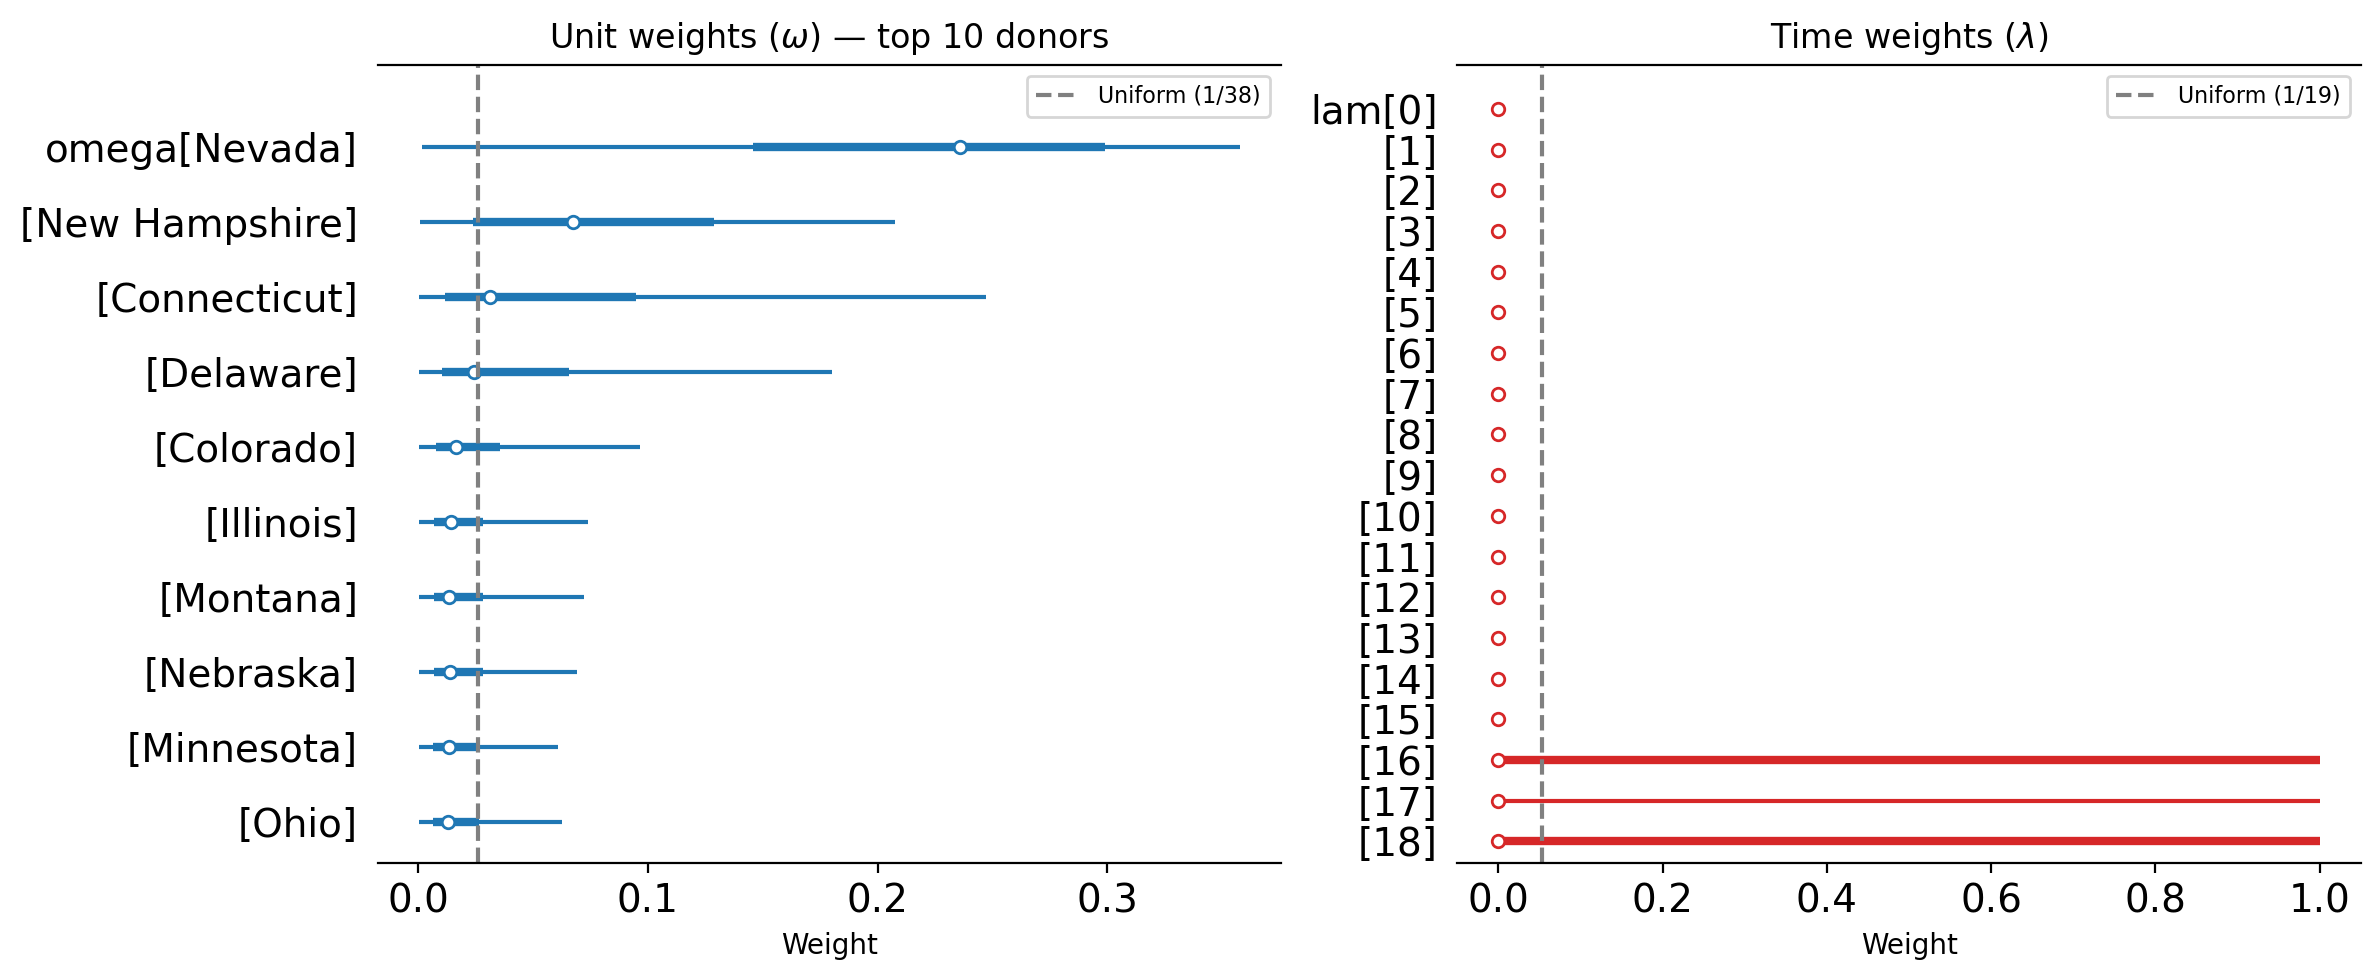

In [6]:
# Pick top 10 donors by posterior mean for omega
omega = result.model.idata.posterior["omega"]
omega_mean = omega.mean(dim=["chain", "draw"]).values
top_k = 10
top_donors = list(omega["coeffs"].values[np.argsort(omega_mean)[::-1][:top_k]])

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Unit weights forest plot (top 10 donors)
az.plot_forest(
    result.model.idata,
    var_names=["omega"],
    coords={"coeffs": top_donors},
    combined=True,
    hdi_prob=0.94,
    ax=axes[0],
    colors="C0",
)
axes[0].axvline(
    1 / len(control_units),
    color="grey",
    linestyle="--",
    label=f"Uniform (1/{len(control_units)})",
)
axes[0].set(xlabel="Weight", title=r"Unit weights ($\omega$) — top 10 donors")
axes[0].legend(fontsize=8)

# Time weights forest plot
az.plot_forest(
    result.model.idata,
    var_names=["lam"],
    combined=True,
    hdi_prob=0.94,
    ax=axes[1],
    colors="C3",
)
T_pre = result.datapre.shape[0]
axes[1].axvline(1 / T_pre, color="grey", linestyle="--", label=f"Uniform (1/{T_pre})")
axes[1].set(xlabel="Weight", title=r"Time weights ($\lambda$)")
axes[1].legend(fontsize=8)

fig.tight_layout()

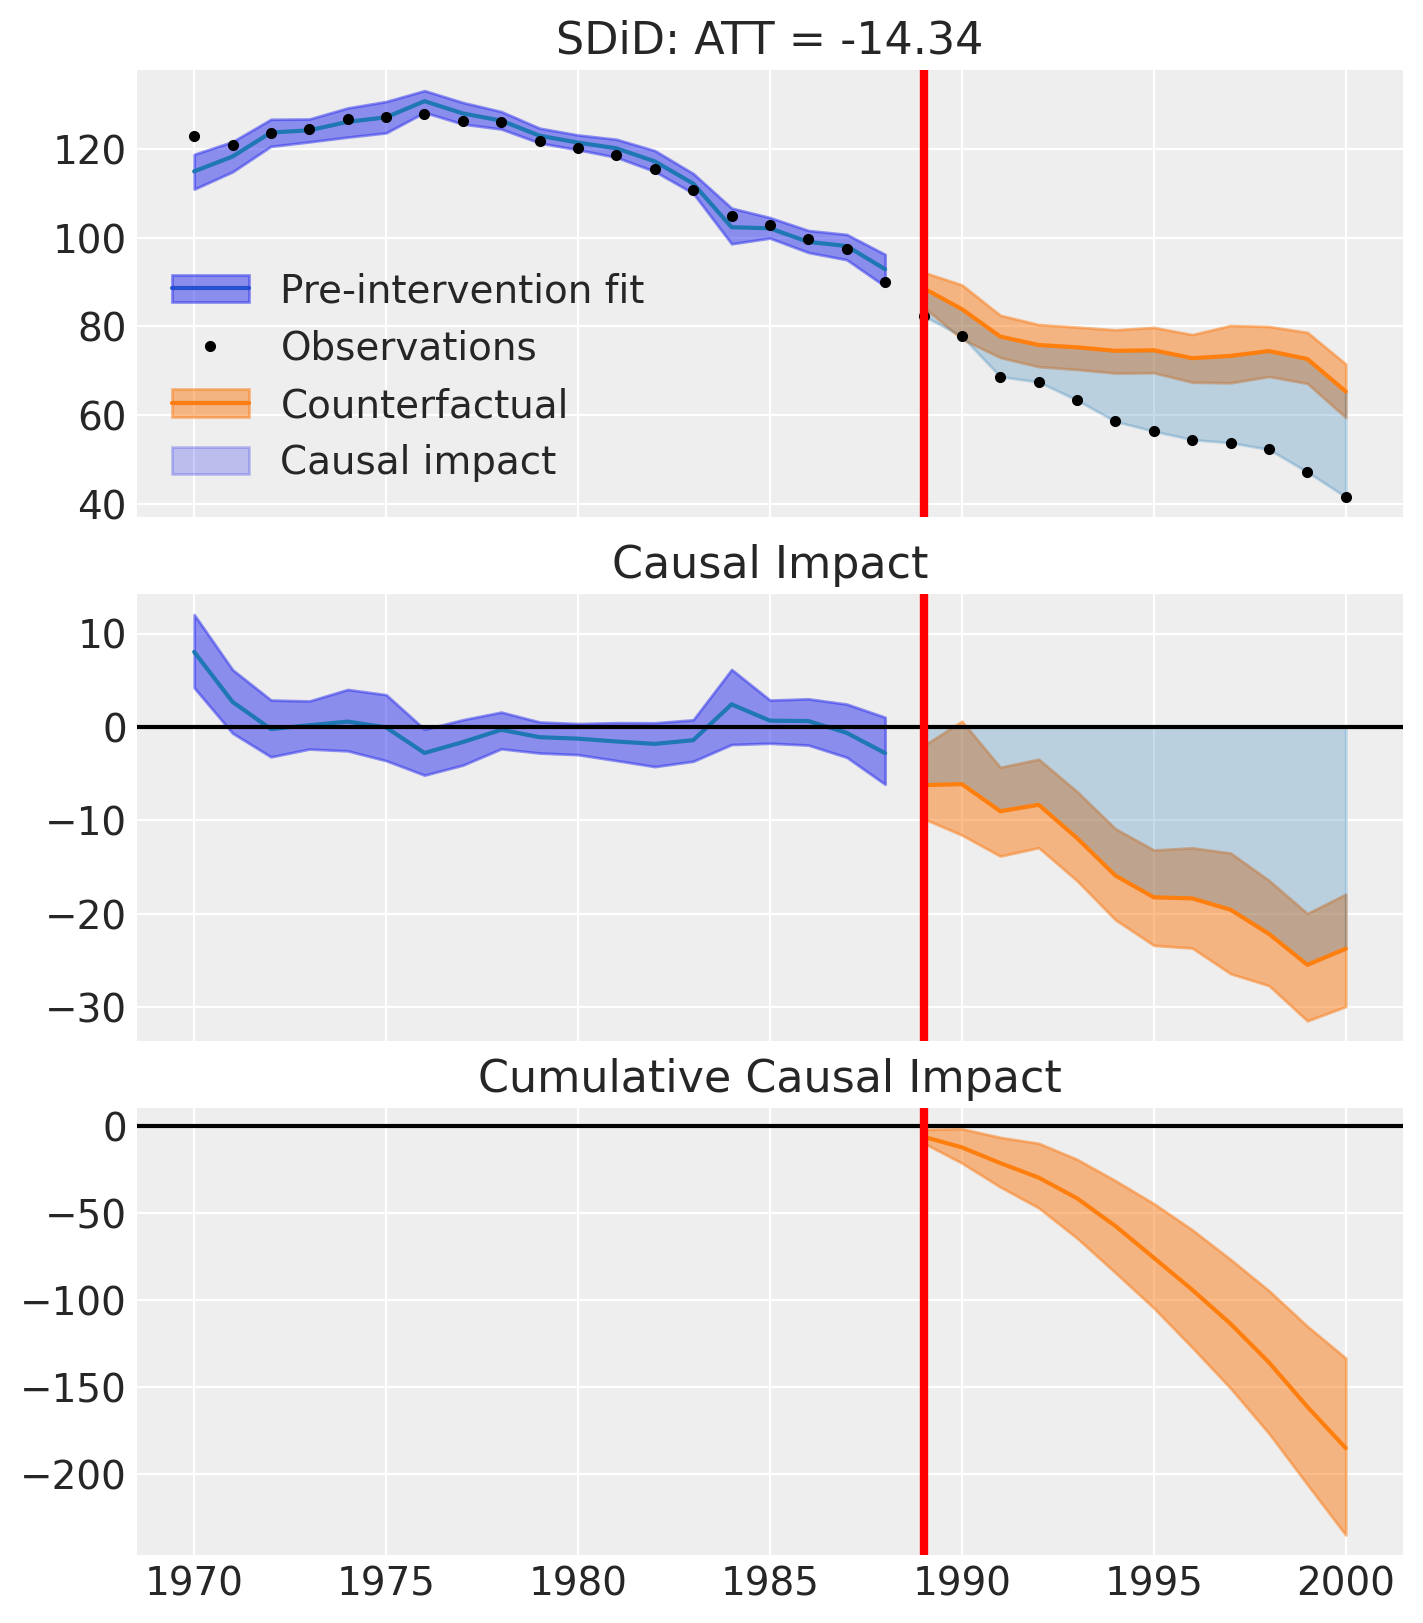

In [7]:
fig, ax = result.plot()

## Effect summary reporting

For decision-making, you often need a concise summary of the causal effect with key statistics. The `effect_summary()` method provides a decision-ready report with average and cumulative effects, HDI intervals, tail probabilities, and relative effects.

In [8]:
stats = result.effect_summary(treated_unit="California")
stats.table

,mean,median,hdi_lower,hdi_upper,p_gt_0,relative_mean,relative_hdi_lower,relative_hdi_upper
average,-15.418321,-15.316368,-19.867753,-11.084570,0.0,-20.277588,-24.767277,-15.517094
cumulative,-185.019855,-183.796414,-238.413038,-133.014835,0.0,-20.277588,-24.767277,-15.517094


In [9]:
print(stats.text)

During the Post-period (1989 to 2000), the response variable had an average value of approx. 60.35. By contrast, in the absence of an intervention, we would have expected an average response of 75.77. The 95% interval of this counterfactual prediction is [71.43, 80.22]. Subtracting this prediction from the observed response yields an estimate of the causal effect the intervention had on the response variable. This effect is -15.42 with a 95% interval of [-19.87, -11.08].

Summing up the individual data points during the Post-period, the response variable had an overall value of 724.20. By contrast, had the intervention not taken place, we would have expected a sum of 909.22. The 95% interval of this prediction is [857.21, 962.61].

The 95% HDI of the effect [-19.87, -11.08] does not include zero. The posterior probability of a decrease is 1.000. Relative to the counterfactual, the effect represents a -20.28% change (95% HDI [-24.77%, -15.52%]).

This analysis assumes that the control u

## Comparison to Synthetic Control

It is instructive to compare SDiD to the standard Synthetic Control method on the same dataset. The key differences are:

- **SC** uses only unit weights to construct the counterfactual. The counterfactual at each post-treatment time point is simply a weighted average of the control units.
- **SDiD** additionally uses time weights that discount uninformative pre-treatment periods, and computes the treatment effect via a double-difference that adjusts for any residual level shift.

In practice, SDiD tends to produce tighter confidence intervals when the pre-treatment fit is already good, because the time weights can down-weight noisy early periods. When the parallel-trends assumption holds approximately (as in a DiD setting), SDiD can also be more robust than SC because the double-differencing removes common time trends that the unit weights alone cannot capture.

/Users/thomaspinder/Developer/CausalPy/causalpy/experiments/synthetic_control.py:118: UserWarning: Control units ['Alabama' (r=-0.148), 'Arkansas' (r=-0.363), 'Georgia' (r=-0.240), 'Tennessee' (r=-0.460)] have pre-treatment correlation below 0.0 or undefined with treated unit 'California'. Consider excluding them from the donor pool. Use cp.plot_correlations() to inspect. See Abadie (2021) for guidance on donor pool selection.
  self._check_donor_correlations()
Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, y_hat_sigma]


Output()

Sampling 4 chains for 3_000 tune and 2_000 draw iterations (12_000 + 8_000 draws total) took 14 seconds.


...

Sampling: [beta, y_hat, y_hat_sigma]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


Sampling: [y_hat]


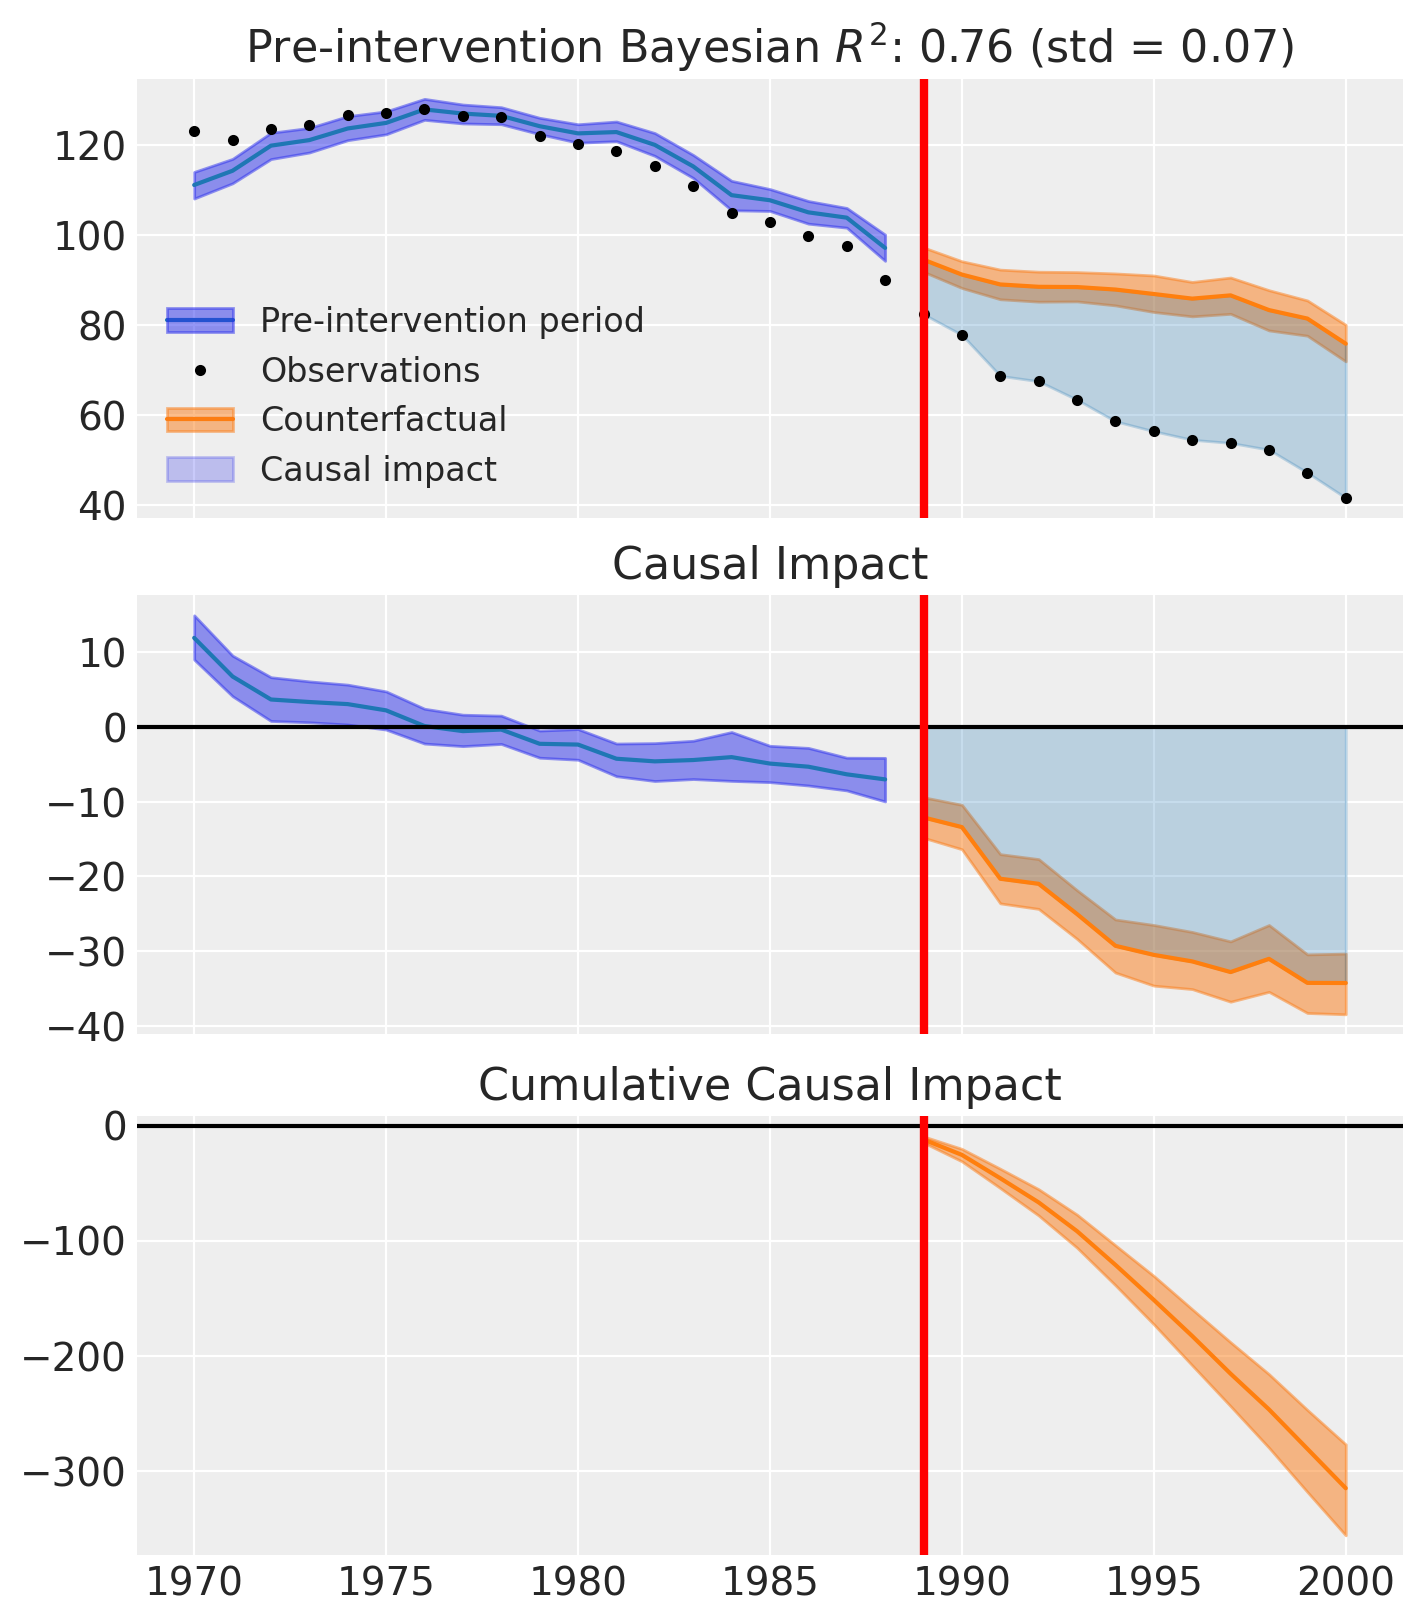

In [10]:
sc_result = cp.SyntheticControl(
    df,
    treatment_time,
    control_units=control_units,
    treated_units=treated_units,
    model=cp.pymc_models.WeightedSumFitter(
        sample_kwargs={
            "target_accept": 0.95,
            "random_seed": seed,
            "tune": 3000,
            "draws": 2000,
        }
    ),
)
fig, ax = sc_result.plot()

### Comparing treatment effect posteriors

We can directly overlay the posterior distributions of the average treatment effect (ATT) from both methods. For SC, the ATT is the mean of the period-by-period impact across the post-treatment window. For SDiD, the ATT is computed analytically via the double-difference formula. Differences in location reflect bias from unaccounted-for time trends; differences in spread reflect the efficiency gain (or loss) from SDiD's time-weighting.

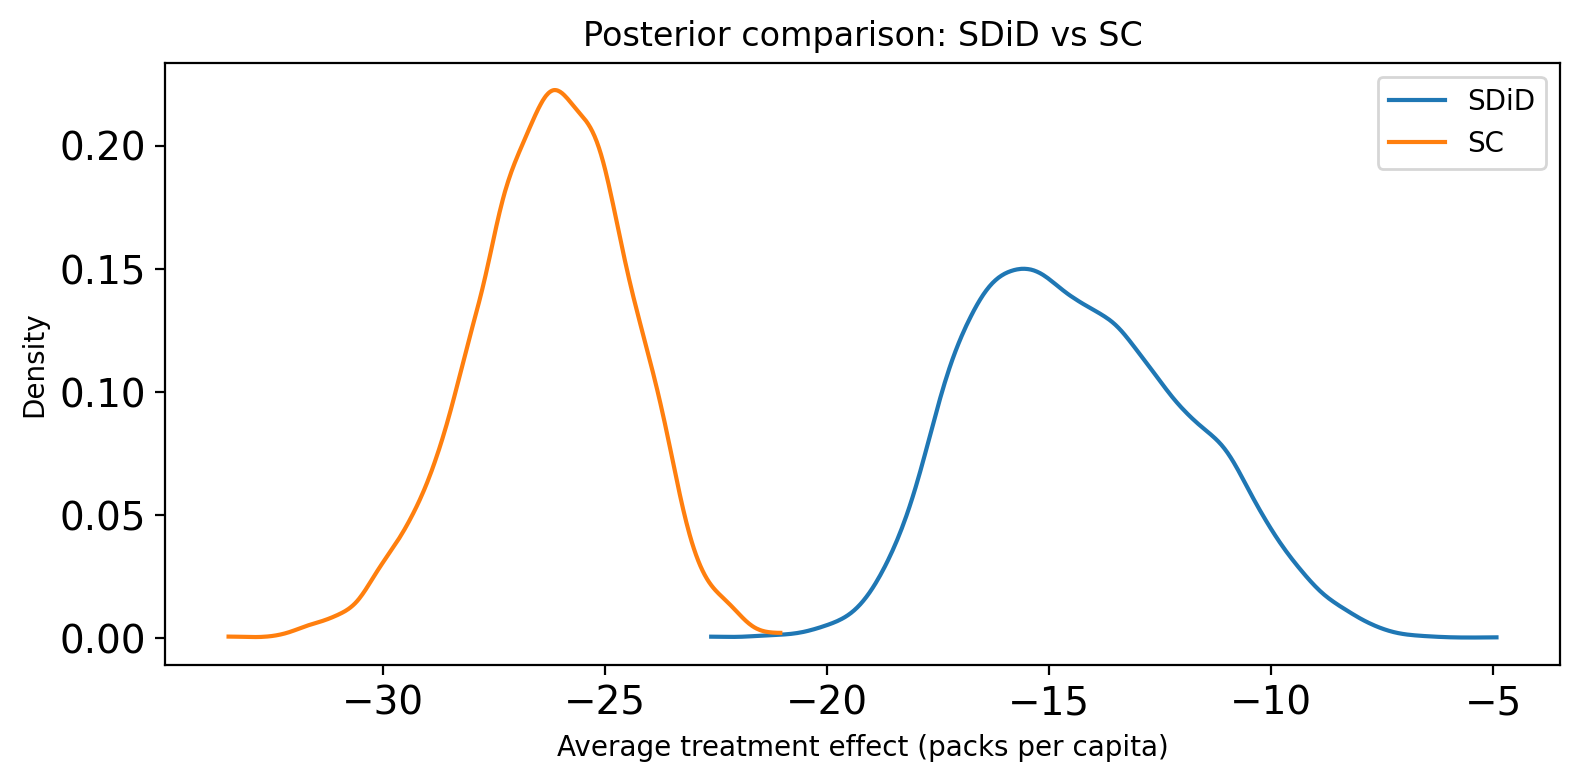

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))

# SDiD: ATT posterior (already in packs per capita)
sdid_tau = result.tau_posterior.values.flatten()

# SC: ATT posterior = mean of post_impact across post-treatment periods
sc_tau = (
    sc_result.post_impact.sel(treated_units="California")
    .mean(dim="obs_ind")
    .values.flatten()
)

az.plot_kde(sdid_tau, ax=ax, label="SDiD", plot_kwargs={"color": "C0"})
az.plot_kde(sc_tau, ax=ax, label="SC", plot_kwargs={"color": "C1"})
ax.set(
    xlabel="Average treatment effect (packs per capita)",
    ylabel="Density",
    title="Posterior comparison: SDiD vs SC",
)
ax.legend()
fig.tight_layout()

### When to prefer SDiD over SC

- **Parallel-trends structure**: If the control and treated units share a common time trend that the unit weights alone cannot fully absorb, SDiD's time weights and double-differencing can remove this residual bias.
- **Noisy early periods**: When early pre-treatment observations are noisy or uninformative, SDiD's time weights automatically down-weight them, leading to a more efficient estimator.
- **Sparse donor pool**: With very few suitable control units, SC may struggle to achieve good pre-treatment fit. SDiD can compensate via its time-weighting mechanism.
- **When SC already works well**: If the synthetic control achieves near-perfect pre-treatment fit and the treatment effect is large, the two methods will typically agree closely. In such cases, SC's simplicity may be preferable.

## References
:::{bibliography}
:filter: docname in docnames
:::